In [1]:
import os
import re
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from functools import reduce
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from scipy.optimize import curve_fit
from astroquery.simbad import Simbad

In [2]:
with open("Star_Configurations/current_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Example access:
print(cfg["main_star"])

UCAC4 754-046742


In [3]:
base_dir = Path(cfg["base_dir"])
print("base_dir = "+str(base_dir))

file_object = cfg["file_object"]
print("file_object = "+str(file_object))

main_star = cfg["main_star"]
print("main_star = "+main_star)

file_nights = cfg["file_nights"].keys()
file_nights = list(file_nights)
print("file_nights = "+str(file_nights))

star_period = cfg["star_period"]
print("star_period = "+str(star_period))

base_dir = data
file_object = Standards_1
main_star = UCAC4 754-046742
file_nights = ['2024_03_05']
star_period = 1.0


In [4]:
colour_list_all = []
for file_night in file_nights:
    colour_list = cfg['file_nights'][str(file_night)]["colour_list"]
    colour_list_all.append(colour_list)
unique_colour_entries = sorted(set(item for sublist in colour_list_all for item in sublist))
print(unique_colour_entries)

['Bader_JC_B', 'Bader_JC_R', 'Bader_JC_U', 'Bader_JC_V', 'ZWO_Blue', 'ZWO_Green', 'ZWO_Red']


# Sorting data

In [5]:
# Load Landolt catalog
landolt_stars = pd.read_csv("data/landolt_north.csv", delimiter="|")
landolt_stars.columns = ['oid', 'main_id', 'ra', 'dec']
landolt_names = set(landolt_stars["main_id"].str.strip())

In [6]:
# Add 'ids' field to SIMBAD queries
Simbad.reset_votable_fields()
Simbad.add_votable_fields("ids")

def get_simbad_aliases(star_name):
    if not isinstance(star_name, str) or star_name.strip() == "":
        return []
    try:
        result = Simbad.query_object(star_name)
        if result is not None and len(result) > 0:
            aliases = result["ids"][0].split(" | ")
            return aliases
        else:
            return []
    except Exception as e:
        print(f"SIMBAD query failed for {star_name}: {e}")
        return []

In [7]:
def read_data(file_path, colour):
    try:
        df = pd.read_csv(file_path, usecols=[
            "Saturated", "matched_id", "matched_MAIN_ID", "Source_Mag_norm", "Source_Mag_Error_norm", "Air mass"
        ])
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")
        return pd.DataFrame()

    # Filter out saturated stars and rows without matched_id
    df = df[(df["Saturated"] != True) & (df["matched_id"].notna())]

    # Rename columns
    df = df.rename(columns={
        "matched_MAIN_ID": "star_name",
        "Source_Mag_norm": "instrumental_mag",
        # "Source_Mag_Error_norm": "instrumental_mag_err",
        "Air mass": "air_mass"
    })

    # Create fallback index: use star_name if available, else matched_id
    df["star_index"] = df["star_name"].fillna(df["matched_id"])

    # Add filter info
    df["filter"] = colour

    return df[["star_index", "matched_id", "star_name", "filter", "instrumental_mag", "air_mass"]]  # , "instrumental_mag_err"]

In [8]:
# Collect all data
long_data = []

for colour in unique_colour_entries:
    folder = base_dir / file_object / file_nights[0] / "Light" / colour / "photometry_matched_norm"
    for file in os.listdir(folder):
        if file.endswith(".csv"):
            file_path = folder / file
            df = read_data(file_path, colour)
            if not df.empty:
                long_data.append(df)

# Combine all rows
long_df = pd.concat(long_data, ignore_index=True)

# Create lookup table before pivot
lookup = long_df[["star_index", "matched_id", "star_name"]].drop_duplicates()

# Pivot to wide format
stars = long_df.pivot_table(
    index="star_index",
    columns="filter",
    values=["instrumental_mag", "air_mass"],
    aggfunc="mean"
)

# Flatten MultiIndex columns
stars.columns = [f"{col[1]}_{col[0]}" for col in stars.columns]
stars = stars.reset_index()

# Merge back matched_id and star_name
stars = stars.merge(lookup, on="star_index", how="left")

In [9]:
stars["simbad_aliases"] = stars["star_name"].apply(get_simbad_aliases)
# Convert alias strings to lists
stars["simbad_aliases"] = stars["simbad_aliases"].apply(
    lambda x: x[0].split("|") if isinstance(x, list) and len(x) > 0 else []
)
# Normalise Landolt names
landolt_names = set(landolt_stars["main_id"].str.strip())

# Check if any Landolt name appears in the aliases list
def is_landolt_alias(alias_list):
    return any(alias.strip() in landolt_names for alias in alias_list)

# Apply to stars
stars["is_landolt_star"] = stars["simbad_aliases"].apply(is_landolt_alias)

In [10]:
def get_simbad_uvbri_magnitudes(star_name):
    if not isinstance(star_name, str) or star_name.strip() == "":
        return {}
    try:
        Simbad.reset_votable_fields()
        Simbad.add_votable_fields("U", "B", "V", "R", "I")

        result = Simbad.query_object(star_name)
        if result is not None and len(result) > 0:
            result_df = result.to_pandas()
            result_df = result_df.apply(lambda col: col.map(lambda x: None if np.ma.is_masked(x) else x))
            row = result_df.iloc[0]
            return {
                "U_mag": row.get("U", None),
                "B_mag": row.get("B", None),
                "V_mag": row.get("V", None),
                "R_mag": row.get("R", None),
                "I_mag": row.get("I", None)
            }
        else:
            return {}
    except Exception as e:
        print(f"SIMBAD magnitude query failed for {star_name}: {e}")
        return {}



def extract_gaia_dr3_id(aliases):
    for alias in aliases:
        match = re.match(r"Gaia DR3 (\d+)", alias.strip())
        if match:
            return match.group(1)
    return None



def get_gaia_magnitudes(gaia_id):
    if gaia_id is None:
        return {}

    try:
        query = f"""
        SELECT phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
        FROM gaiadr3.gaia_source
        WHERE source_id = {gaia_id}
        """
        job = Gaia.launch_job(query)
        result = job.get_results()

        if len(result) > 0:
            row = result[0]
            return {
                "BP_mag": row["phot_bp_mean_mag"],
                "RP_mag": row["phot_rp_mean_mag"],
                "G_mag": row["phot_g_mean_mag"]
            }
        else:
            return {}
    except Exception as e:
        print(f"Gaia query failed for {gaia_id}: {e}")
        return {}

In [11]:

#Query SIMBAD for UVBRI magnitudes
uvbri_data = stars["star_name"].apply(get_simbad_uvbri_magnitudes)

# Convert to DataFrame and merge
uvbri_df = pd.DataFrame(uvbri_data.tolist())
stars = pd.concat([stars, uvbri_df], axis=1)

stars["gaia_dr3_id"] = stars["simbad_aliases"].apply(extract_gaia_dr3_id)


In [12]:

gaia_data = stars["gaia_dr3_id"].apply(get_gaia_magnitudes)
gaia_df = pd.DataFrame(gaia_data.tolist())
stars = pd.concat([stars, gaia_df], axis=1)


In [13]:
#Renaming columns to make reading easier
stars.rename(columns={'Bader_JC_U_instrumental_mag': 'U_ins_mag',
                      'Bader_JC_B_instrumental_mag': 'B_ins_mag',
                      'Bader_JC_V_instrumental_mag': 'V_ins_mag',
                      'Bader_JC_R_instrumental_mag': 'R_ins_mag',
                      'ZWO_Blue_instrumental_mag': 'ZWO_Blue_ins_mag',
                      'ZWO_Green_instrumental_mag': 'ZWO_Green_ins_mag',
                      'ZWO_Red_instrumental_mag': 'ZWO_Red_ins_mag'}, inplace=True)

In [14]:


#stars['U_zp'] = stars['U_ins_mag'] - stars['U_mag']      # No stars found with this filter
stars['B_zp'] = stars['B_ins_mag'] - stars['B_mag']
stars['V_zp'] = stars['V_ins_mag'] - stars['V_mag']
stars['R_zp'] = stars['R_ins_mag'] - stars['R_mag']

#stars['U_app_mag'] = stars['U_ins_mag'] - stars['U_zp'].mean()
stars['B_app_mag'] = stars['B_ins_mag'] - stars['B_zp'].mean()
stars['V_app_mag'] = stars['V_ins_mag'] - stars['V_zp'].mean()
stars['R_app_mag'] = stars['R_ins_mag'] - stars['R_zp'].mean()



In [15]:
stars['Colour'] = stars['B_ins_mag'] - stars['V_ins_mag']

In [16]:
stars.to_csv(f"data/{file_object}_stars_data.csv", index=False)

# Filter Transforms

In [17]:
# Load both standards files
files = ["Standards_1_stars_data.csv", "Standards_2_stars_data.csv"]

# Read and concatenate
standards_dfs = [pd.read_csv(base_dir / f) for f in files]
stars = pd.concat(standards_dfs, ignore_index=True)


In [18]:
# Eq for filter transformation:

def model(inputs, a, b, c):
    x_mag, airmass, colour = inputs
    return x_mag + a + b * airmass + c * colour


In [19]:
from_filter = 'ZWO_Blue'
to_filter = 'B'

# Prepare raw arrays
x_mag = stars[f"{from_filter}_ins_mag"].values
airmass = stars[f"{from_filter}_air_mass"].values
colour = stars["Colour"].values
y_mag = stars[f"{to_filter}_ins_mag"].values

# Stack inputs and target for filtering
data_matrix = np.column_stack((x_mag, airmass, colour, y_mag))

# Filter out rows with NaNs or infs
clean_data = data_matrix[np.isfinite(data_matrix).all(axis=1)]

# Unpack cleaned inputs
x_mag_clean, airmass_clean, colour_clean, y_mag_clean = clean_data.T
inputs_clean = (x_mag_clean, airmass_clean, colour_clean)

# Fit the model
params, covariance = curve_fit(model, inputs_clean, y_mag_clean, p0=[1, 1, 1])
a_fit, b_fit, c_fit = params

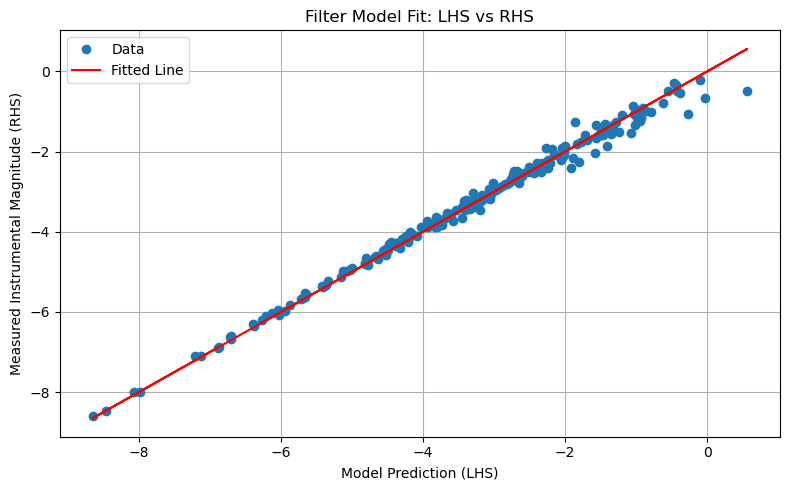

Fitted parameters:
a = 0.6261, b = -0.2893, c = 0.3912


In [20]:
# Compute fitted values
y_fit = model(inputs_clean, *params)

# Compute LHS using fitted parameters
lhs = x_mag_clean + a_fit + b_fit * airmass_clean + c_fit * colour_clean
rhs = y_mag_clean  # actual instrumental magnitude

# Plot LHS vs RHS with fitted line
plt.figure(figsize=(8, 5))
plt.plot(lhs, rhs, 'o', label='Data')
plt.plot(lhs, y_fit, 'r-', label='Fitted Line')  # fitted model output
plt.title("Filter Model Fit: LHS vs RHS")
plt.xlabel("Model Prediction (LHS)")
plt.ylabel("Measured Instrumental Magnitude (RHS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Fitted parameters:\na = {a_fit:.4f}, b = {b_fit:.4f}, c = {c_fit:.4f}")